Given that the data has now been processed, It is now time to visualize the dataset, and answer these questions:

1.  **Human Impact**
-   What is the total toll
-   Who is most at risk
-   What are the worst incidents

2.  **Geographic Analysis**
-   Where are the danger zones
-   Which specific locations are hazardous?

3.  **Temporal Analysis**
-   What time of day is deadliest?
-   Are there weekly or seasonal trends?

4.  **Causation & Vehicle Types**
-   What is driving these crashes?
-   Are certain factors deadlier?
-   What vehicles are involved?
-   Do certain vehicle combinations cause worse crashes?

This notebook will verify the data using seaborn and matplotlib before getting fed to powerBI for the final output.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.float_format = '{:.2f}'.format #limits decimal place to 2 for all columns
df = pd.read_csv("./dataset/cleaned_crash_data.csv")

C:\Users\Ross\AppData\Local\Temp\ipykernel_15368\3898267154.py:7: DtypeWarning: Columns (0: zip_code) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./dataset/cleaned_crash_data.csv")


In [ ]:
# Sanity checks
injury_cols = [
    'number_of_persons_injured', 'number_of_persons_killed',
    'number_of_pedestrians_injured', 'number_of_pedestrians_killed',
    'number_of_cyclist_injured', 'number_of_cyclist_killed',
    'number_of_motorist_injured', 'number_of_motorist_killed'
]

print(df[injury_cols].describe())

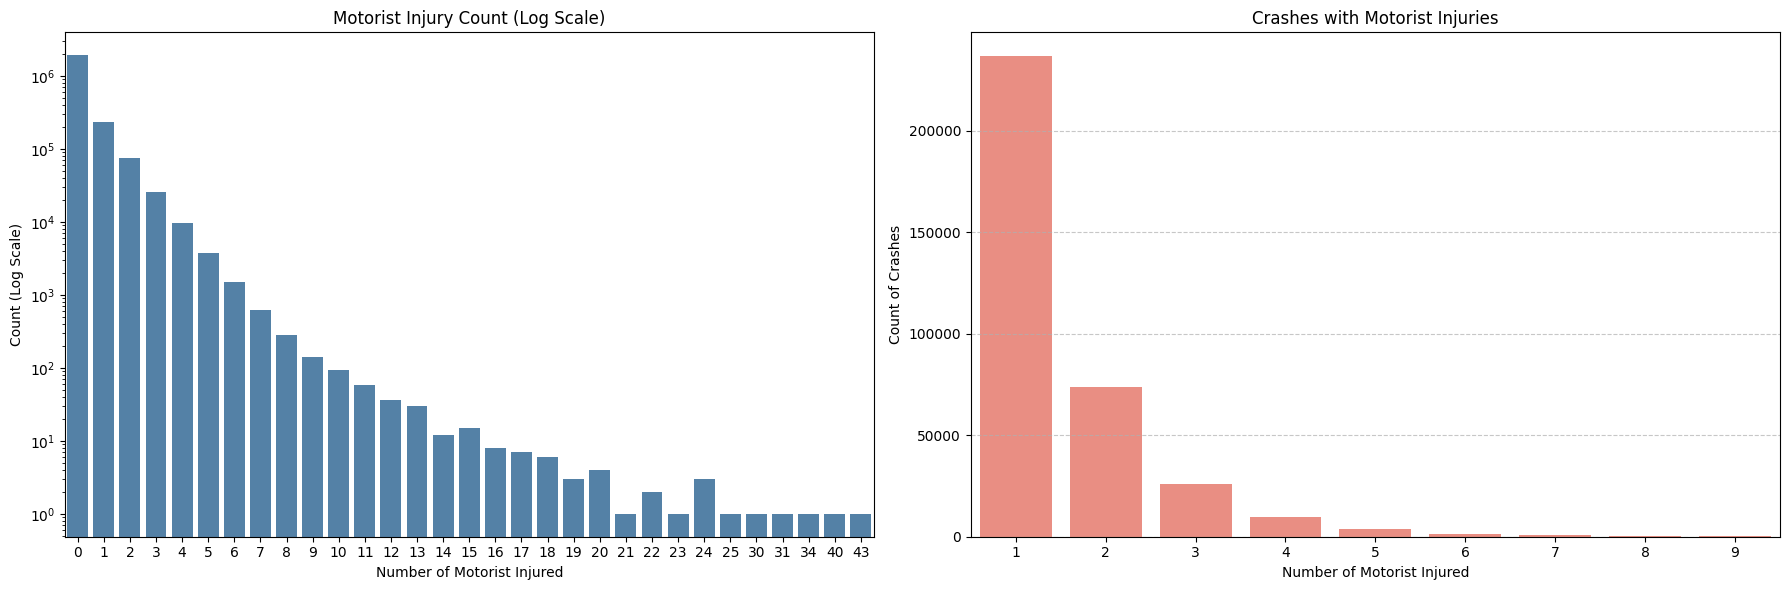

In [2]:
# Univariate Analysis: Motorist injured per crashes
fig, ax = plt.subplots(1,2,figsize=(18, 6))

# Log Scale for left plot for distribution of motorist crashes
sns.countplot(data=df, x='number_of_motorist_injured', ax=ax[0], color='steelblue')
ax[0].set_yscale('log')
ax[0].set_title('Motorist Injury Count (Log Scale)')
ax[0].set_xlabel('Number of Motorist Injured')
ax[0].set_ylabel('Count (Log Scale)')

# Filtered Right plot to look for actual injuries
motorist_injured_filtered = df[df['number_of_motorist_injured'] > 0]
sns.countplot(data=motorist_injured_filtered,x='number_of_motorist_injured',ax=ax[1], color='salmon')
ax[1].set_title('Crashes with Motorist Injuries')
ax[1].set_xlabel('Number of Motorist Injured')
ax[1].set_ylabel('Count of Crashes')
ax[1].grid(axis='y', linestyle='--', alpha=0.7)
ax[1].set_xlim(-0.5,8.5)

plt.tight_layout()
plt.show()

borough
NaN              690421
BROOKLYN         505824
QUEENS           421596
MANHATTAN        347866
BRONX            233604
STATEN ISLAND     65898
Name: count, dtype: int64


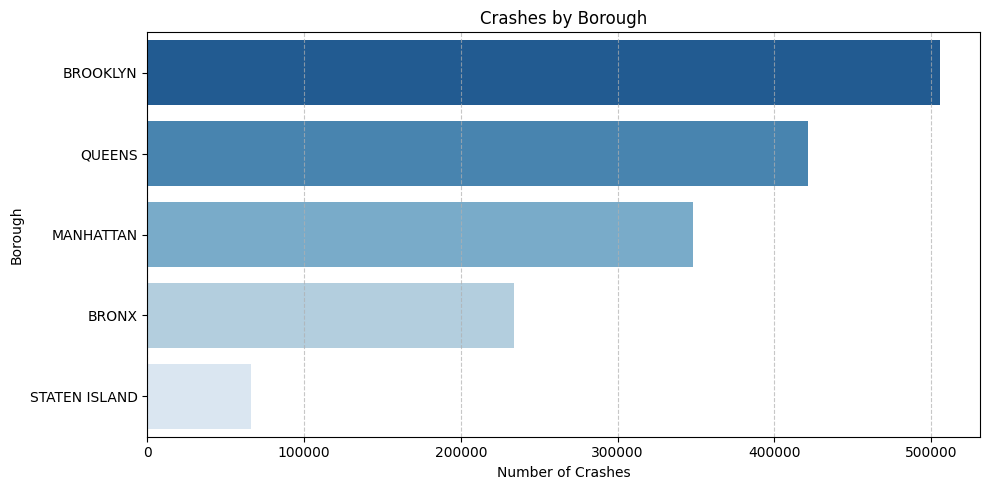

In [ ]:
# Univariate Analysis: Crashes per Borough
print(df['borough'].value_counts(dropna=False))
borough_order = df['borough'].value_counts().index

# Visualization
plt.figure(figsize=(10,5))
sns.countplot(data=df, y='borough',order=df['borough'].value_counts().index, hue='borough',hue_order=borough_order,palette='Blues_r',legend=False)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.title('Crashes by Borough')
plt.xlabel('Number of Crashes')
plt.ylabel('Borough')

plt.tight_layout()
plt.show()

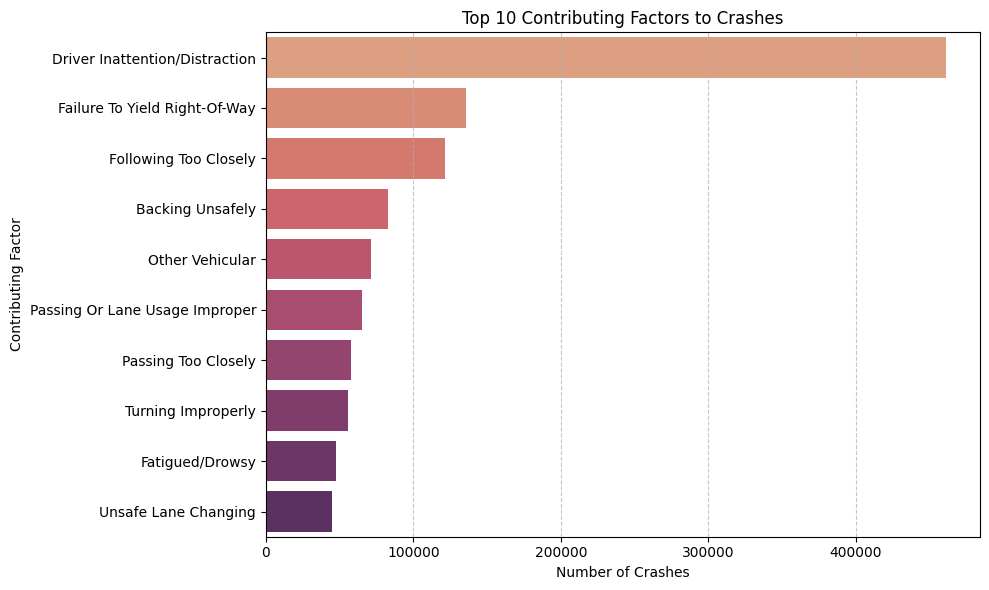

In [ ]:
# Univariate Analysis: Top 10 Contributing Factors
filtered_df = df[df['contributing_factor_vehicle_1'] != 'Unspecified'] # Filter 'Unspecified' for clearer insights
top_factors = filtered_df['contributing_factor_vehicle_1'].value_counts().head(10)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(x=filtered_df['contributing_factor_vehicle_1'].value_counts().head(10).values, y=top_factors.index, hue=top_factors.index,palette='flare')
plt.title('Top 10 Contributing Factors to Crashes')
plt.grid(axis='x', linestyle='--',alpha=0.7)
plt.xlabel('Number of Crashes')
plt.ylabel('Contributing Factor')

plt.tight_layout()
plt.show()

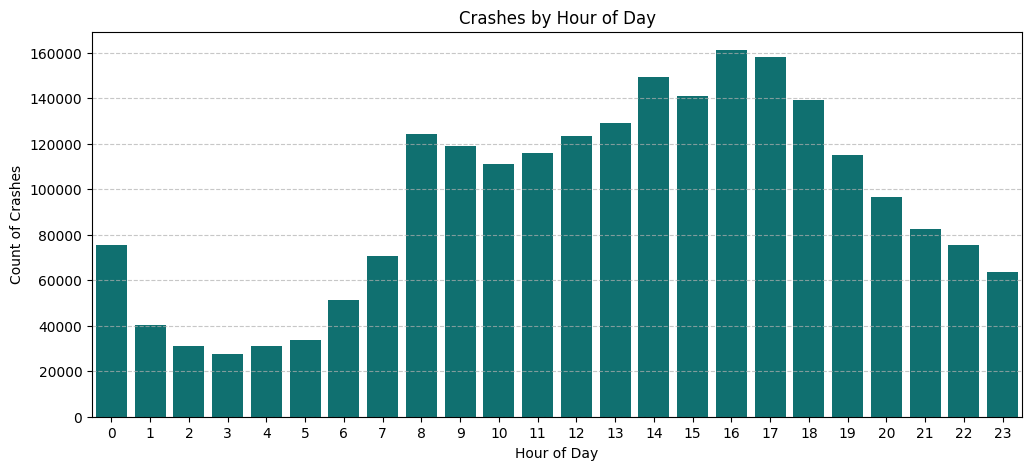

In [ ]:
# Univariate Analysis: Frequency of Crashes by Hour of Day
df['crash_datetime'] = pd.to_datetime(df['crash_datetime']) # Convert to datetime
df['crash_hour'] = df['crash_datetime'].dt.hour # Convert to Hour of Day

# Visualization
plt.figure(figsize=(12,5))
sns.countplot(data=df,x='crash_hour',color='teal')
plt.title('Crashes by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Count of Crashes')
plt.xticks(range(0,24)) #Limit x-axis to 24 hours
plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.show()


AVG: borough
BROOKLYN        0.36
BRONX           0.35
QUEENS          0.32
STATEN ISLAND   0.30
MANHATTAN       0.23
Name: number_of_persons_injured, dtype: float64


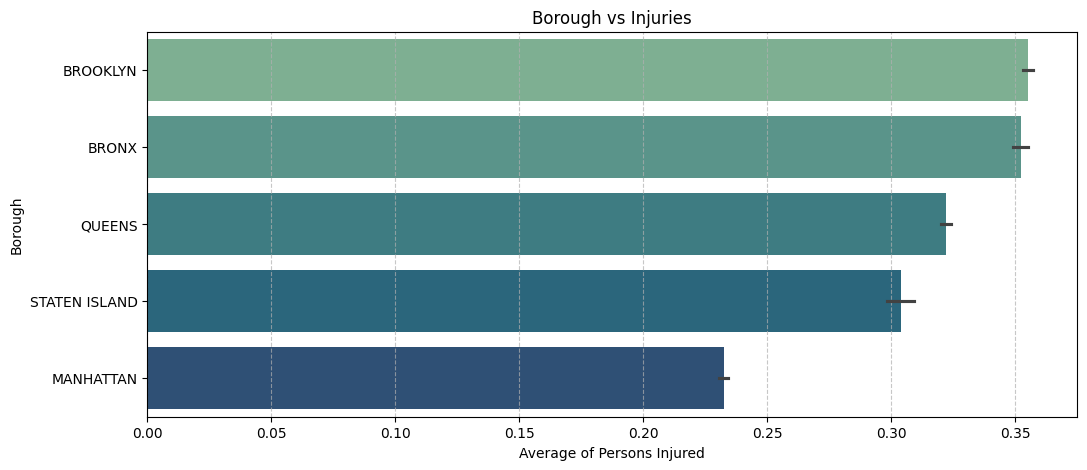

In [ ]:
# Bivariate Analysis: Mean of Injuries by Bourough 
# Categorical vs Numerical Test
borough_injuries = df.groupby('borough')['number_of_persons_injured'].mean().sort_values(ascending=False) # Group by borough, query persons injured
print(f"AVG: {borough_injuries}")

# Visualization
plt.figure(figsize=(12,5))
sns.barplot(data=df, x='number_of_persons_injured',y='borough', order=borough_injuries.index,hue_order=borough_injuries.index,hue='borough',palette='crest',legend=False)
plt.title('Borough vs Injuries')
plt.xlabel('Average of Persons Injured')
plt.ylabel('Borough')
plt.grid(axis='x',linestyle='--',alpha=0.7)

plt.show()